# **Washington State Electric Vehicle Analysis**

INFO 432 Final Project

Summer 2026

Group 3

Shreya Arya, Kriti Sundaresa, Flora Zheng, Han Truong, Ashni Kumar​

# Introduction

EV ownership is growing rapidly, which is increasing the need for accessible public charging infrastructure. However, charging stations may not always be distributed proportionally to where EV owners actually live. Areas with a high number of EV registrations but relatively few charging stations could experience infrastructure gaps that make EV ownership less convenient. Limited access to charging may also discourage further EV adoption, especially in areas outside major urban and commercial centers. Improving the placement of charging stations can help support continued EV adoption while also contributing to reductions in transportation-related emissions. Washington is a useful case study because it has high EV adoption across a mix of urban, suburban, and rural communities. This analysis serves as a framework that can be applied to other geographic locations. Electric vehicle companies, local governments, EV oweners and prospective EV owners would all be interested in an analysis of EV vehicle registrations and charging stations in close proximity.

Datasets:
1. https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2/about_data
2. "Electric Vehicle Charging Stations" Dataset from https://ev-map-wsdot.hub.arcgis.com/pages/data

# Data Preprocessing

In [ ]:
install.packages("tidyverse")
install.packages("ggplot2")
install.packages("viridis")

library(dplyr)
library(tidyverse)
library(ggplot2)
library(viridis)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘gridExtra’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Load

In [ ]:
df <- read.csv("/content/alt_fuel_stations (Jul 28 2026).csv", stringsAsFactors = FALSE)
print(head(df))
cat("Shape: ", nrow(df), " rows, ", ncol(df), " columns\n")
print(colnames(df))

  Fuel.Type.Code                                           Station.Name
1           ELEC Seattle-Tacoma International Airport - General Parking
2           ELEC                                            Avista Corp
3           ELEC                                    Steam Plant Parking
4           ELEC                                 BELLEVUE BELLEVUE CH 1
5           ELEC                         KING COUNTY DES ISSAQUAH P&R 2
6           ELEC                        UWB CASCADIA CC NORTH LEVEL 3 N
        Street.Address                          Intersection.Directions
1  17801 Pacific Hwy S                         7th floor parking garage
2   1411 E Mission Ave                                                 
3        130 S Post St                                                 
4     450 110th Ave NE           Visitor Parking. First Left-hand Turn.
5 1755 Highlands Dr NE                                           garage
6  18500 Campus Way NE Just to the right as you enter the north 

In [ ]:
ev_df <- read.csv("/content/Electric_Vehicle_Population_Data_20260825.csv", stringsAsFactors = FALSE)
print(head(ev_df))
cat("Shape: ", nrow(ev_df), " rows, ", ncol(ev_df), " columns\n")
print(colnames(ev_df))

  VIN..1.10.   County         City State Postal.Code Model.Year    Make   Model
1 5YJ3E1EA5L   Yakima       Yakima    WA       98908       2020   TESLA MODEL 3
2 5YJ3E1EA9K Thurston      Olympia    WA       98502       2019   TESLA MODEL 3
3 5YJSA1H22F   Kitsap     Kingston    WA       98346       2015   TESLA MODEL S
4 KM8K33AG7L     King      Seattle    WA       98107       2020 HYUNDAI    KONA
5 5YJ3E1EB1K   Yakima       Yakima    WA       98902       2019   TESLA MODEL 3
6 JN1AZ0CP6B   Kitsap Port Orchard    WA       98366       2011  NISSAN    LEAF
           Electric.Vehicle.Type
1 Battery Electric Vehicle (BEV)
2 Battery Electric Vehicle (BEV)
3 Battery Electric Vehicle (BEV)
4 Battery Electric Vehicle (BEV)
5 Battery Electric Vehicle (BEV)
6 Battery Electric Vehicle (BEV)
  Clean.Alternative.Fuel.Vehicle..CAFV..Eligibility Electric.Range
1           Clean Alternative Fuel Vehicle Eligible            266
2           Clean Alternative Fuel Vehicle Eligible            220
3       

In [ ]:
missing_counts <- colSums(is.na(df))
print(missing_counts)

missing_percentages <- round(colMeans(is.na(df)) * 100, 2)
cat("\nPercent missing:\n")
print(missing_percentages)

                         Fuel.Type.Code                            Station.Name 
                                      0                                       0 
                         Street.Address                 Intersection.Directions 
                                      0                                       0 
                                   City                                   State 
                                      0                                       0 
                                    ZIP                                   Plus4 
                                      0                                    3180 
                          Station.Phone                             Status.Code 
                                      4                                       0 
                          Expected.Date                 Groups.With.Access.Code 
                                   3180                                       0 
                       Acces

In [ ]:
#dropping electric ranges of 0 for years 2021-2027
drop_condition <- ev_df$Electric.Range == 0 &
                  ev_df$Model.Year >= 2021 &
                  ev_df$Model.Year <= 2027

drop_condition[is.na(drop_condition)] <- FALSE

ev_df_clean <- ev_df[!drop_condition, ]

cat("Before: ", nrow(ev_df), " rows\n")
cat("After:  ", nrow(ev_df_clean), " rows\n")
cat("Dropped:", sum(drop_condition), " rows\n")

Before:  294193  rows
After:   101796  rows
Dropped: 192397  rows


After the year 2020, new BEVs have an electric range of 300 miles or more so they were no longer maintained and zeros were entered, significantly diluting our results.

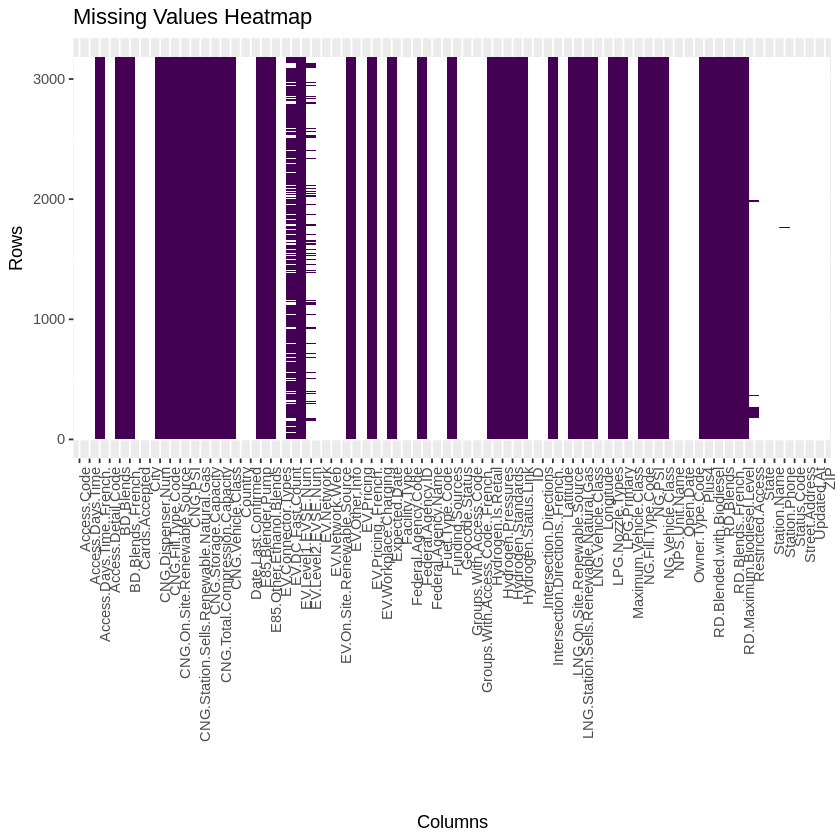

In [ ]:
df_missing_logical <- as.data.frame(is.na(df)) %>%
  mutate(row_id = row_number())

df_long <- df_missing_logical %>%
  pivot_longer(cols = -row_id, names_to = "column", values_to = "is_missing")

ggplot(df_long, aes(x = column, y = row_id, fill = is_missing)) +
  geom_tile() +
  scale_fill_manual(values = c("TRUE" = "#440154FF", "FALSE" = "white")) + # Using a hex code from viridis
  labs(title = "Missing Values Heatmap", x = "Columns", y = "Rows") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1), legend.position = "none")

In [ ]:
# Clean the mapping: drop NaNs, convert float Postal Codes to integers first, then to strings
zip_county_map <- ev_df %>%
  select(Postal.Code, County) %>%
  na.omit() %>%
  distinct()

# Convert Postal.Code to integer then to character in zip_county_map_r
zip_county_map$Postal.Code <- as.character(as.integer(zip_county_map$Postal.Code))

# Clean df_r$ZIP to ensure matching string format
df$ZIP <- as.character(df$ZIP)

In [ ]:
# Left join County into stations DataFrame
df <- df %>%
  left_join(zip_county_map, by = c("ZIP" = "Postal.Code"))

# Display the first few rows of the merged data frame
print(head(df))

Warning message in left_join(., zip_county_map, by = c(ZIP = "Postal.Code")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 6 of `x` matches multiple rows in `y`.
ℹ Row 78 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


  Fuel.Type.Code                                           Station.Name
1           ELEC Seattle-Tacoma International Airport - General Parking
2           ELEC                                            Avista Corp
3           ELEC                                    Steam Plant Parking
4           ELEC                                 BELLEVUE BELLEVUE CH 1
5           ELEC                         KING COUNTY DES ISSAQUAH P&R 2
6           ELEC                        UWB CASCADIA CC NORTH LEVEL 3 N
        Street.Address                          Intersection.Directions
1  17801 Pacific Hwy S                         7th floor parking garage
2   1411 E Mission Ave                                                 
3        130 S Post St                                                 
4     450 110th Ave NE           Visitor Parking. First Left-hand Turn.
5 1755 Highlands Dr NE                                           garage
6  18500 Campus Way NE Just to the right as you enter the north 

In [ ]:
names(df)

[1] "Fuel.Type.Code"                         
 [2] "Station.Name"                           
 [3] "Street.Address"                         
 [4] "Intersection.Directions"                
 [5] "City"                                   
 [6] "State"                                  
 [7] "ZIP"                                    
 [8] "Plus4"                                  
 [9] "Station.Phone"                          
[10] "Status.Code"                            
[11] "Expected.Date"                          
[12] "Groups.With.Access.Code"                
[13] "Access.Days.Time"                       
[14] "Cards.Accepted"                         
[15] "BD.Blends"                              
[16] "NG.Fill.Type.Code"                      
[17] "NG.PSI"                                 
[18] "EV.Level1.EVSE.Num"                     
[19] "EV.Level2.EVSE.Num"                     
[20] "EV.DC.Fast.Count"                       
[21] "EV.Other.Info"                          
[22] "EV.Network"                             
[23] "EV.Network.Web"                         
[24] "Geocode.Status"                         
[25] "Latitude"                               
[26] "Longitude"                              
[27] "Date.Last.Confirmed"                    
[28] "ID"                                     
[29] "Updated.At"                             
[30] "Owner.Type.Code"                        
[31] "Federal.Agency.ID"                      
[32] "Federal.Agency.Name"                    
[33] "Open.Date"                              
[34] "Hydrogen.Status.Link"                   
[35] "NG.Vehicle.Class"                       
[36] "LPG.Primary"                            
[37] "E85.Blender.Pump"                       
[38] "EV.Connector.Types"                     
[39] "Country"                                
[40] "Intersection.Directions..French."       
[41] "Access.Days.Time..French."              
[42] "BD.Blends..French."                     
[43] "Groups.With.Access.Code..French."       
[44] "Hydrogen.Is.Retail"                     
[45] "Access.Code"                            
[46] "Access.Detail.Code"                     
[47] "Federal.Agency.Code"                    
[48] "Facility.Type"                          
[49] "CNG.Dispenser.Num"                      
[50] "CNG.On.Site.Renewable.Source"           
[51] "CNG.Total.Compression.Capacity"         
[52] "CNG.Storage.Capacity"                   
[53] "LNG.On.Site.Renewable.Source"           
[54] "E85.Other.Ethanol.Blends"               
[55] "EV.Pricing"                             
[56] "EV.Pricing..French."                    
[57] "LPG.Nozzle.Types"                       
[58] "Hydrogen.Pressures"                     
[59] "Hydrogen.Standards"                     
[60] "CNG.Fill.Type.Code"                     
[61] "CNG.PSI"                                
[62] "CNG.Vehicle.Class"                      
[63] "LNG.Vehicle.Class"                      
[64] "EV.On.Site.Renewable.Source"            
[65] "Restricted.Access"                      
[66] "RD.Blends"                              
[67] "RD.Blends..French."                     
[68] "RD.Blended.with.Biodiesel"              
[69] "RD.Maximum.Biodiesel.Level"             
[70] "NPS.Unit.Name"                          
[71] "CNG.Station.Sells.Renewable.Natural.Gas"
[72] "LNG.Station.Sells.Renewable.Natural.Gas"
[73] "Maximum.Vehicle.Class"                  
[74] "EV.Workplace.Charging"                  
[75] "Funding.Sources"                        
[76] "County"

# Advanced EDA

In [ ]:
# ---------------------------------------------------------
# EVs per Charging Station by County
# ---------------------------------------------------------

# Count EV registrations by county
county_ev_counts <- ev_df %>%
  filter(!is.na(County)) %>%
  count(County, name = "EV_Count")

# Count charging stations by county
county_station_counts <- df %>%
  filter(!is.na(County)) %>%
  count(County, name = "Charging_Stations")

# Combine the two datasets
county_charging_need <- county_ev_counts %>%
  left_join(county_station_counts, by = "County") %>%

  # Counties with no recorded stations will get 0
  mutate(
    Charging_Stations = replace_na(Charging_Stations, 0),

    # Calculate EVs per charger
    EVs_Per_Charger = ifelse(
      Charging_Stations > 0,
      EV_Count / Charging_Stations,
      NA
    )
  ) %>%

  # Highest EVs per charger = potentially most underserved
  arrange(desc(EVs_Per_Charger))

# View results
county_charging_need

County,EV_Count,Charging_Stations,EVs_Per_Charger
<chr>,<int>,<int>,<dbl>
Kitsap,10185,62,164.27419
Cowlitz,1636,10,163.60000
Snohomish,37128,260,142.80000
Pierce,24578,187,131.43316
Island,3226,25,129.04000
Clark,18365,160,114.78125
Thurston,10806,107,100.99065
King,141971,1549,91.65332
Grant,1234,16,77.12500


In [ ]:
# Top 10 counties with the highest number of EVs per charging station

top_10_underserved <- county_charging_need %>%
  filter(Charging_Stations > 0) %>%
  slice_max(
    order_by = EVs_Per_Charger,
    n = 10
  )

top_10_underserved

County,EV_Count,Charging_Stations,EVs_Per_Charger
<chr>,<int>,<int>,<dbl>
Kitsap,10185,62,164.27419
Cowlitz,1636,10,163.60000
Snohomish,37128,260,142.80000
Pierce,24578,187,131.43316
Island,3226,25,129.04000
Clark,18365,160,114.78125
Thurston,10806,107,100.99065
King,141971,1549,91.65332
Grant,1234,16,77.12500


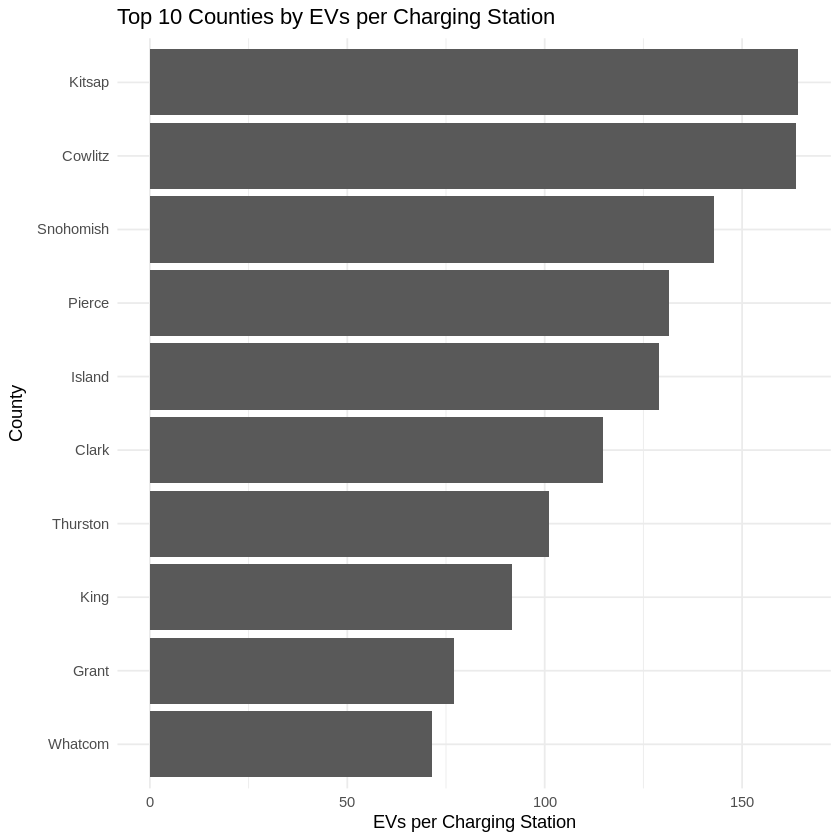

In [ ]:
ggplot(top_10_underserved,
       aes(x = reorder(County, EVs_Per_Charger),
           y = EVs_Per_Charger)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 Counties by EVs per Charging Station",
    x = "County",
    y = "EVs per Charging Station"
  ) +
  theme_minimal()

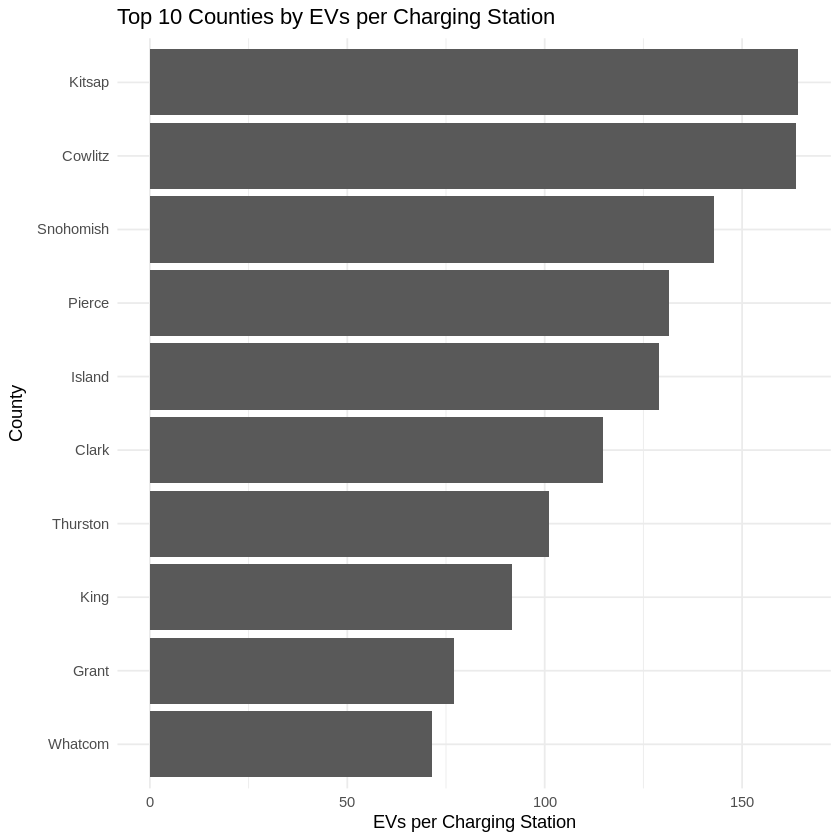

In [ ]:
ggplot(top_10_underserved,
       aes(x = reorder(County, EVs_Per_Charger),
           y = EVs_Per_Charger)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 Counties by EVs per Charging Station",
    x = "County",
    y = "EVs per Charging Station"
  ) +
  theme_minimal()

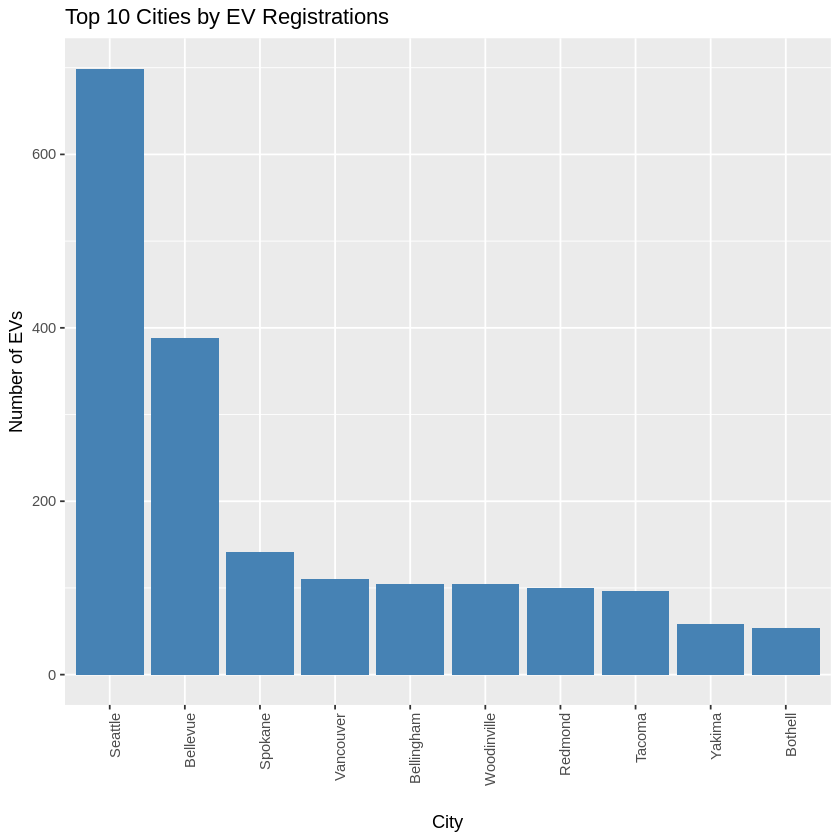

In [ ]:
# Top 10 Cities by EV Registrations

city_ev_count <- df %>%
  count(City, sort = TRUE) %>%
  head(10)

ggplot(city_ev_count, aes(x = reorder(City, -n), y = n)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(title = "Top 10 Cities by EV Registrations", x = "City", y = "Number of EVs") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


In [ ]:
# counties with the highest need for chargers
charging_need <- ev_df %>%
  group_by(County) %>%
  summarise(EV_Count = n(),
            Avg_range = mean(`Electric.Range`, na.rm = TRUE)) %>%
  arrange(desc(EV_Count)) %>%
  head(10)

print(charging_need)

# A tibble: 10 × 3
   County    EV_Count Avg_range
   <chr>        <int>     <dbl>
 1 King        140130      36.1
 2 Snohomish    36508      33.9
 3 Pierce       24162      37.1
 4 Clark        18060      37.4
 5 Thurston     10617      39.5
 6 Kitsap       10023      39.2
 7 Spokane       8329      35.1
 8 Whatcom       7205      43.6
 9 Benton        4304      48.5
10 Skagit        3440      43.4


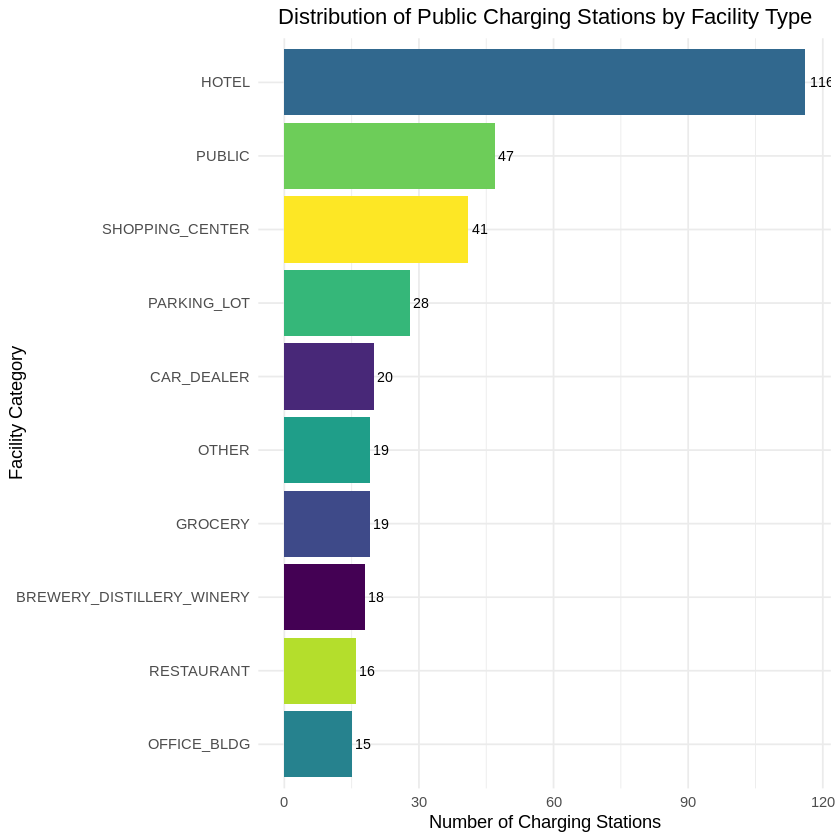

In [ ]:
facility_counts <- df %>%
  filter(nchar(trimws(`Facility.Type`)) > 0) %>%
  count(`Facility.Type`, sort = TRUE) %>%
  head(10)

ggplot(facility_counts, aes(x = reorder(`Facility.Type`, n), y = n, fill = `Facility.Type`)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = n), hjust = -0.2, size = 3) +
  scale_fill_viridis_d() +
  labs(title = "Distribution of Public Charging Stations by Facility Type", x = "Facility Category", y = "Number of Charging Stations") +
  coord_flip() +
  theme_minimal() +
  theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


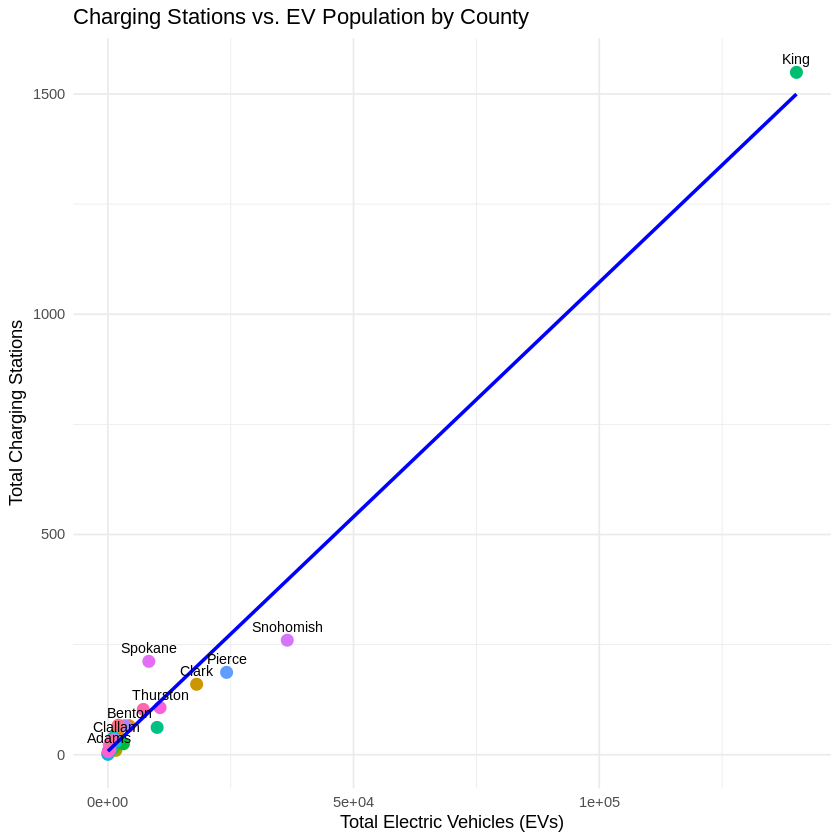

In [ ]:
# 1. Aggregate station counts by County
station_counts_by_county <- df %>%
  filter(nchar(trimws(`County`)) > 0) %>%
  group_by(County) %>%
  summarise(Station_Count = n()) %>%
  ungroup()

# 2. Aggregate EV counts by County ev_df
ev_counts_by_county <- ev_df %>%
  filter(nchar(trimws(`County`)) > 0) %>%
  group_by(County) %>%
  summarise(EV_Count = n()) %>%
  ungroup()

# 3. Merge the two aggregated dataframes
county_summary <- left_join(station_counts_by_county, ev_counts_by_county, by = "County")

# Handle NAs that might result from counties with no stations or no EVs
county_summary[is.na(county_summary)] <- 0

# 4. Visualize the relationship: EV Count vs. Station Count per County
# Filtering for counties with at least one EV
county_summary_plot <- county_summary %>%
  filter(EV_Count > 0)

# Create the scatter plot
p <- ggplot(county_summary_plot, aes(x = EV_Count, y = Station_Count, label = County)) +
  geom_point(aes(color = County), size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "blue") + # Add a linear regression line
  geom_text(vjust = -0.8, hjust = 0.5, size = 3, check_overlap = TRUE) + # Label points with County names
  labs(
    title = "Charging Stations vs. EV Population by County",
    x = "Total Electric Vehicles (EVs)",
    y = "Total Charging Stations"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

print(p)

In [ ]:
# 1. Identify High and Low EV Counties
# Let's define 'high-EV' as top 25% and 'low-EV' as bottom 25% of counties by EV_Count
quantile_25 <- quantile(county_summary$EV_Count, 0.25)
quantile_75 <- quantile(county_summary$EV_Count, 0.75)

high_ev_counties <- county_summary %>%
  filter(EV_Count >= quantile_75) %>%
  select(County)

low_ev_counties <- county_summary %>%
  filter(EV_Count <= quantile_25 & EV_Count > 0) %>%
  select(County)

# 2. Filter Station Data for these counties
stations_high_ev <- df %>%
  filter(County %in% high_ev_counties$County)

stations_low_ev <- df %>%
  filter(County %in% low_ev_counties$County)


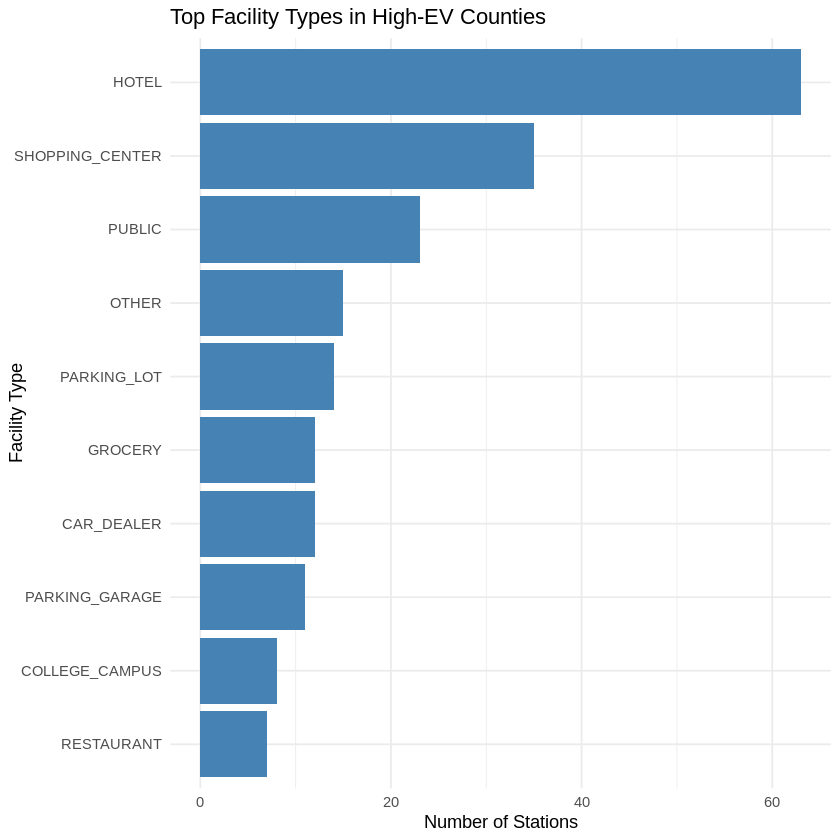

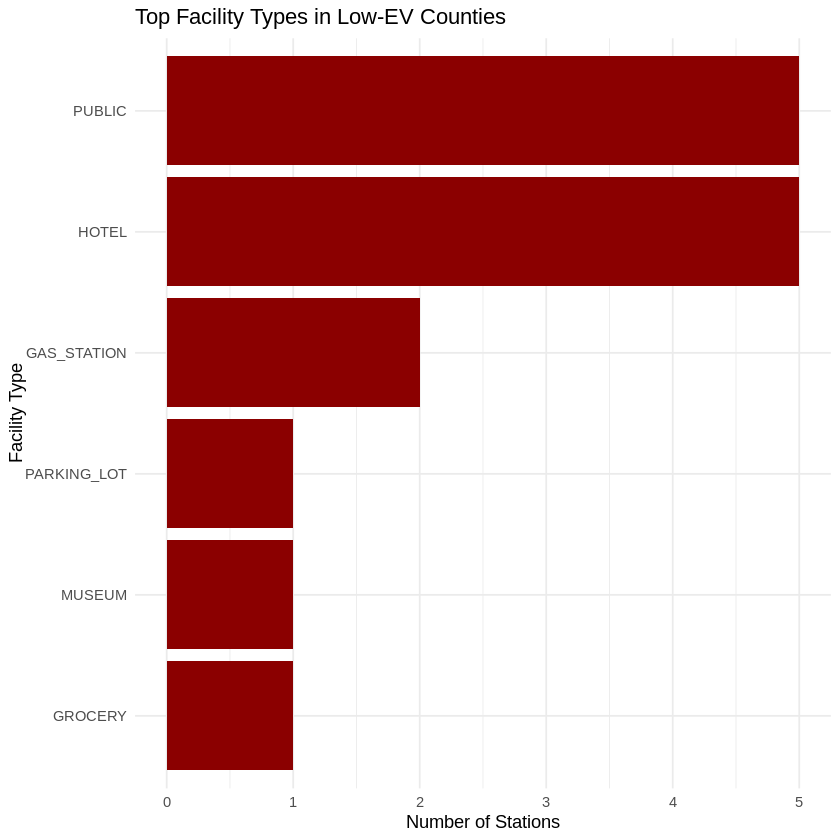

In [ ]:
# 3. Analyze and Visualize Facility Type distribution
# For High-EV Counties
facility_high_ev <- stations_high_ev %>%
  filter(nchar(trimws(`Facility.Type`)) > 0) %>%
  group_by(Facility.Type) %>%
  summarise(Count = n()) %>%
  arrange(desc(Count)) %>%
  head(10) # Top 10 facility types

p_facility_high <- ggplot(facility_high_ev, aes(x = reorder(Facility.Type, Count), y = Count)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top Facility Types in High-EV Counties",
    x = "Facility Type",
    y = "Number of Stations"
  ) +
  theme_minimal()
print(p_facility_high)

# For Low-EV Counties
facility_low_ev <- stations_low_ev %>%
  filter(nchar(trimws(`Facility.Type`)) > 0) %>%
  group_by(Facility.Type) %>%
  summarise(Count = n()) %>%
  arrange(desc(Count)) %>%
  head(10) # Top 10 facility types

p_facility_low <- ggplot(facility_low_ev, aes(x = reorder(Facility.Type, Count), y = Count)) +
  geom_bar(stat = "identity", fill = "darkred") +
  coord_flip() +
  labs(
    title = "Top Facility Types in Low-EV Counties",
    x = "Facility Type",
    y = "Number of Stations"
  ) +
  theme_minimal()
print(p_facility_low)

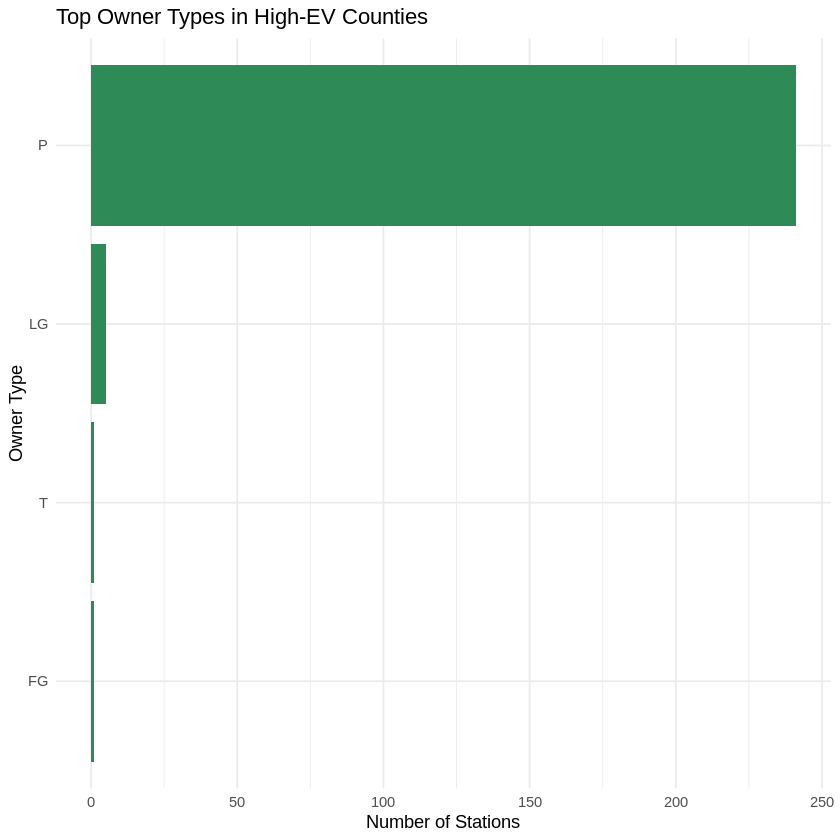

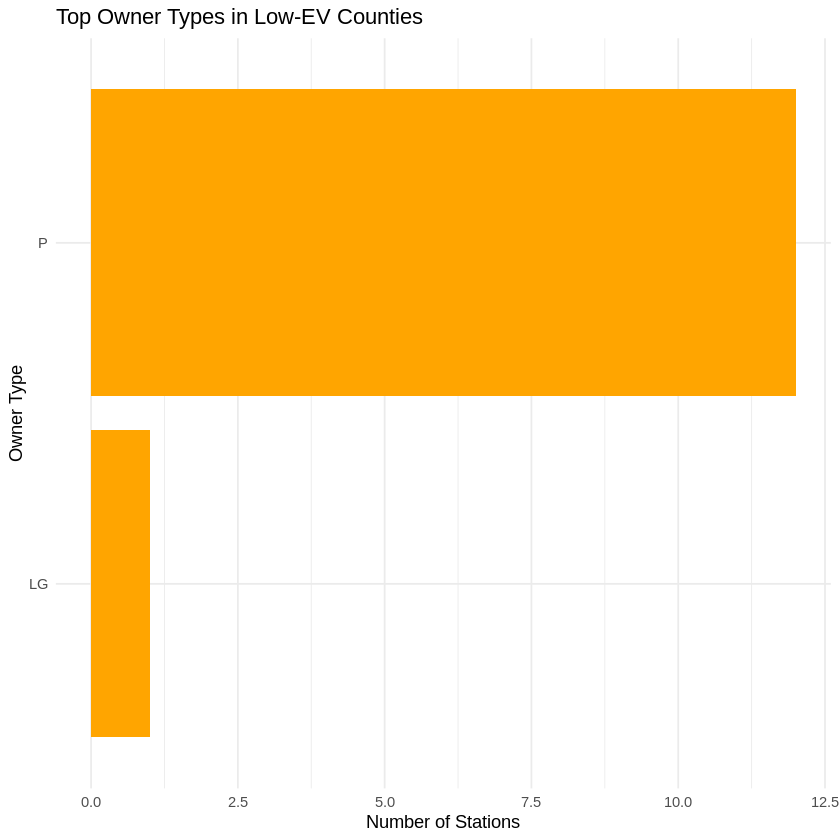

In [ ]:
# Analyze and Visualize Owner Type Code distribution
# For High-EV Counties
owner_high_ev <- stations_high_ev %>%
  filter(nchar(trimws(`Owner.Type.Code`)) > 0) %>%
  group_by(Owner.Type.Code) %>%
  summarise(Count = n()) %>%
  arrange(desc(Count)) %>%
  head(5) # Top 5 owner types

p_owner_high <- ggplot(owner_high_ev, aes(x = reorder(Owner.Type.Code, Count), y = Count)) +
  geom_bar(stat = "identity", fill = "seagreen") +
  coord_flip() +
  labs(
    title = "Top Owner Types in High-EV Counties",
    x = "Owner Type",
    y = "Number of Stations"
  ) +
  theme_minimal()
print(p_owner_high)

# For Low-EV Counties
owner_low_ev <- stations_low_ev %>%
  filter(nchar(trimws(`Owner.Type.Code`)) > 0) %>%
  group_by(Owner.Type.Code) %>%
  summarise(Count = n()) %>%
  arrange(desc(Count)) %>%
  head(5) # Top 5 owner types

p_owner_low <- ggplot(owner_low_ev, aes(x = reorder(Owner.Type.Code, Count), y = Count)) +
  geom_bar(stat = "identity", fill = "orange") +
  coord_flip() +
  labs(
    title = "Top Owner Types in Low-EV Counties",
    x = "Owner Type",
    y = "Number of Stations"
  ) +
  theme_minimal()
print(p_owner_low)

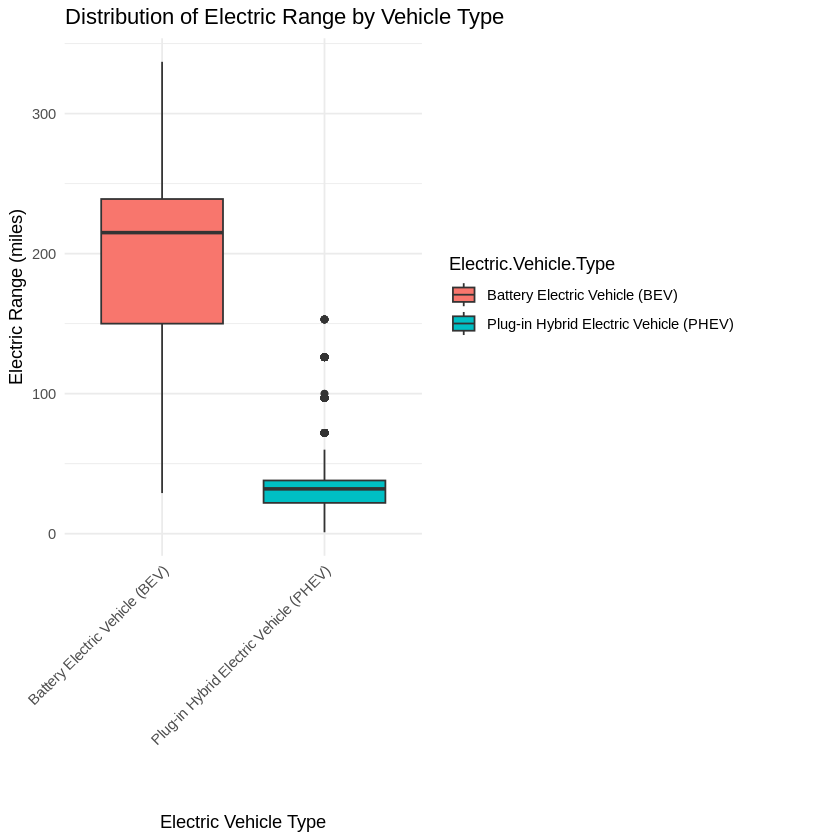

In [ ]:
# Ensure Electric.Range is numeric and filter out NAs and zero values
clean_ev_df_range <- ev_df %>%
  filter(!is.na(`Electric.Range`) & `Electric.Range` > 0)

# Box plot of Electric Range by Electric Vehicle Type
p_range_type <- ggplot(clean_ev_df_range, aes(x = `Electric.Vehicle.Type`, y = `Electric.Range`, fill = `Electric.Vehicle.Type`)) +
  geom_boxplot() +
  labs(
    title = "Distribution of Electric Range by Vehicle Type",
    x = "Electric Vehicle Type",
    y = "Electric Range (miles)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
print(p_range_type)

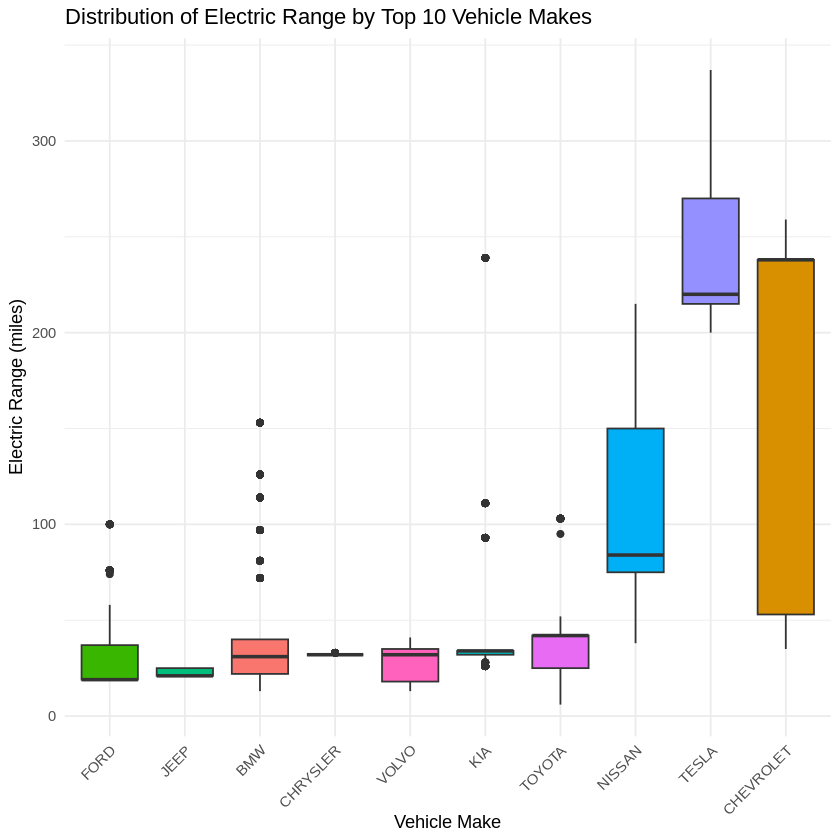

In [ ]:
# Box plot of Electric Range for Top N Makes
# Top 10 Makes by vehicle count
top_makes <- clean_ev_df_range %>%
  group_by(Make) %>%
  summarise(Count = n()) %>%
  arrange(desc(Count)) %>%
  head(10) %>%
  select(Make)

# Filter the dataframe to include only these top Makes
ev_df_top_makes <- clean_ev_df_range %>%
  filter(Make %in% top_makes$Make)

p_range_make <- ggplot(ev_df_top_makes, aes(x = reorder(Make, `Electric.Range`, FUN = median), y = `Electric.Range`, fill = Make)) +
  geom_boxplot() +
  labs(
    title = "Distribution of Electric Range by Top 10 Vehicle Makes",
    x = "Vehicle Make",
    y = "Electric Range (miles)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")
print(p_range_make)

In [ ]:
table(ev_df$'Electric.Vehicle.Type')




        Battery Electric Vehicle (BEV) Plug-in Hybrid Electric Vehicle (PHEV) 
                                233544                                  56020 

# Hypothesis Testing

### Is there a significant positive correlation at a 95% confidence level between a county's electric vehicle population and the number of public EV charging stations available in that county?

*   H0: There is no significant linear relationship between EV Count and Station Count.
*   H1: There is a significant linear relationship between EV Count and Station Count.


Call:
lm(formula = Station_Count ~ EV_Count, data = county_summary)

Residuals:
     Min       1Q   Median       3Q      Max 
-136.645   -5.132    3.045   12.717  115.313 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 8.0270713  6.1884535   1.297    0.203    
EV_Count    0.0106447  0.0002589  41.117   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 36.74 on 37 degrees of freedom
Multiple R-squared:  0.9786,	Adjusted R-squared:  0.978 
F-statistic:  1691 on 1 and 37 DF,  p-value: < 2.2e-16



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


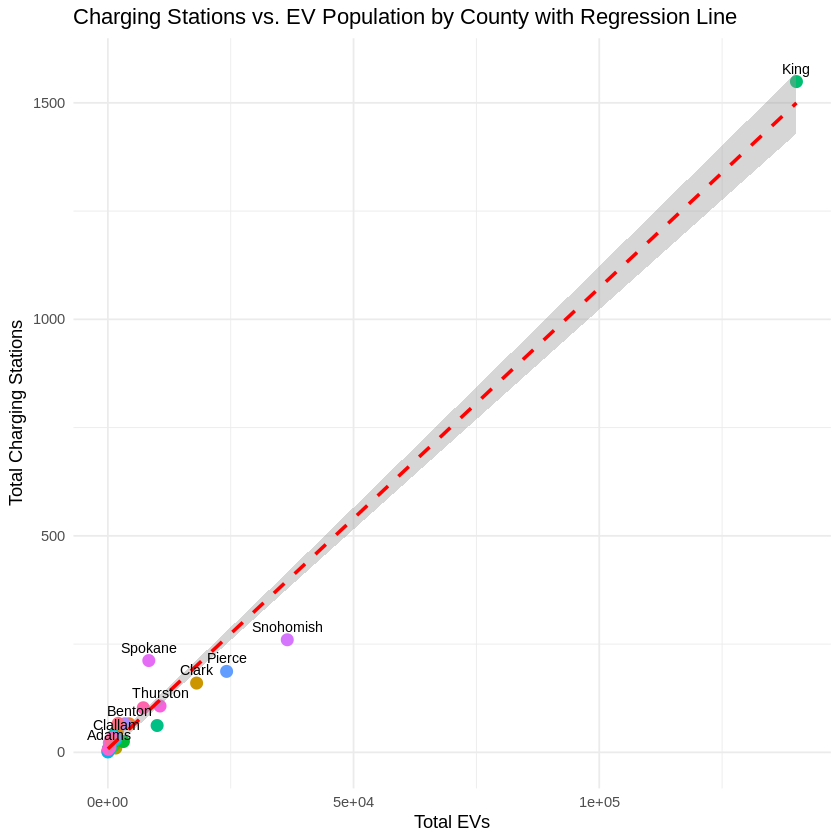

In [ ]:
regression_model <- lm(Station_Count ~ EV_Count, data = county_summary)

print(summary(regression_model))

# Visualize the regression line on the scatterplot
library(ggplot2)

p_reg <- ggplot(county_summary, aes(x = EV_Count, y=Station_Count, label=County)) +
  geom_point(aes(color=County), size=3) +
  geom_smooth(method='lm', se=TRUE, color='red', linetype='dashed') +
  # regression line with conf interval
  geom_text(vjust=-0.8, hjust=0.5, size=3, check_overlap=TRUE) +
  # label points w County names
  labs(
    title='Charging Stations vs. EV Population by County with Regression Line',
    x='Total EVs',
    y='Total Charging Stations'
  ) +
  theme_minimal() +
  theme(legend.position = "none")

print(p_reg)

p-value is a lot below 0.05. We can reject null hypothesis at 95% confidence level. There is a statistically significant relationship between the number of Electrical Vehicles and Charging Stations at each County.

### One-sided t-test: Is Snohomish County's number of charging stations significantly higher than expected? (alpha = 0.05)

*   H0: The true number of charging stations in Snohomish County is less than or equal to the expected value.
*   H1: The true number of charging stations in Snohomish County is significantly higher than the expected value.





In [ ]:
# Extract Snohomish County's data
snohomish_data <- county_summary %>%
  filter(County == "Snohomish")

actual_stations_snohomish <- snohomish_data$Station_Count
ev_count_snohomish <- snohomish_data$EV_Count

# Predict station count for Snohomish using the regression model
predicted_stations_snohomish <- predict(regression_model, newdata = data.frame(EV_Count = ev_count_snohomish))

# Calculate the residual for Snohomish
snohomish_residual <- actual_stations_snohomish - predicted_stations_snohomish

# Get residual standard error from the model summary
residual_std_error <- summary(regression_model)$sigma

# one-sided t-test
t_statistic <- snohomish_residual / residual_std_error

# Degrees of freedom for the residuals
df_residuals <- df.residual(regression_model)

# p-value
p_value <- pt(t_statistic, df = df_residuals, lower.tail = FALSE)

cat("  Actual Stations: ", actual_stations_snohomish, "\n")
cat("  Predicted Stations: ", round(predicted_stations_snohomish, 2), "\n")
cat("  Residual (Actual - Predicted): ", round(snohomish_residual, 2), "\n")
cat("  Residual Standard Error: ", round(residual_std_error, 2), "\n")
cat("  T-statistic: ", round(t_statistic, 2), "\n")
cat("  P-value (one-sided): ", round(p_value, 4), "\n")

  Actual Stations:  260 
  Predicted Stations:  396.65 
  Residual (Actual - Predicted):  -136.65 
  Residual Standard Error:  36.74 
  T-statistic:  -3.72 
  P-value (one-sided):  0.9997 
Conclusion: At a 95% confidence level, Snohomish County does NOT have significantly more charging stations than predicted by its EV population.

At a 95% confidence level, Snohomish County does NOT have significantly more charging stations than predicted by its EV population.

### One-sided t-test: Is Clark County's number of charging stations significantly lower than expected based on its EV population? (alpha = 0.05)

*   H0: The true number of charging stations in Clark County is greater than or equal to the expected value.
*   H1: The true number of charging stations in Clark County is significantly lower than the expected value.



In [ ]:
# Extract Clark County's data
clark_data <- county_summary %>%
  filter(County == "Clark")

actual_stations_clark <- clark_data$Station_Count
ev_count_clark <- clark_data$EV_Count

# Predict station count for Clark using the regression model
predicted_stations_clark <- predict(regression_model, newdata = data.frame(EV_Count = ev_count_clark))

# Calculate the residual for Clark
clark_residual <- actual_stations_clark - predicted_stations_clark

# Get residual standard error from the model summary
residual_std_error <- summary(regression_model)$sigma

# one-sided t-test
t_statistic <- clark_residual / residual_std_error

# Degrees of freedom for the residuals
df_residuals <- df.residual(regression_model)

# p-value <- pt(t_statistic, df = df_residuals, lower.tail = TRUE)

cat("Clark County Data:\n")
cat("  Actual Stations: ", actual_stations_clark, "\n")
cat("  Predicted Stations: ", round(predicted_stations_clark, 2), "\n")
cat("  Residual (Actual - Predicted): ", round(clark_residual, 2), "\n")
cat("  Residual Standard Error: ", round(residual_std_error, 2), "\n")
cat("  T-statistic: ", round(t_statistic, 2), "\n")
cat("  P-value (one-sided): ", round(p_value, 4), "\n")

Clark County Data:
  Actual Stations:  160 
  Predicted Stations:  200.27 
  Residual (Actual - Predicted):  -40.27 
  Residual Standard Error:  36.74 
  T-statistic:  -1.1 
  P-value (one-sided):  0.9997 
Conclusion: At a 95% confidence level, Clark County does NOT have significantly fewer charging stations than predicted by its EV population.

At a 95% confidence level, Clark County does NOT have significantly fewer charging stations than predicted by its EV population.

## Correlation test: Is there a significant correlation between an electric vehicle's model year and its electric range?

H0: No correlation between model year and electric range.

H1: There is a correlation between model year and electric range.

In [ ]:
range_year <- ev_df %>%
  filter(!is.na(Electric.Range) & Electric.Range > 0 & Model.Year <= 2020)

cat("Rows used:", nrow(range_year), "of", nrow(ev_df), "\n")
print(table(range_year$Model.Year))

#Spearman rank correlation
spearman_result <- cor.test(
  range_year$Model.Year,
  range_year$Electric.Range,
  method = "spearman"
)
print(spearman_result)

#Pearson linear check
pearson_result <- cor.test(
  range_year$Model.Year,
  range_year$Electric.Range,
  method = "pearson"
)
print(pearson_result)

Rows used: 62912 of 294193 

 1999  2000  2002  2003  2008  2010  2011  2012  2013  2014  2015  2016  2017 
    3     7     1     1    16    20   527  1287  3806  3093  4335  5000  8355 
 2018  2019  2020 
13864 10728 11869 


Warning message in cor.test.default(range_year$Model.Year, range_year$Electric.Range, :
“cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  range_year$Model.Year and range_year$Electric.Range
S = 1.8626e+13, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.5511891 


	Pearson's product-moment correlation

data:  range_year$Model.Year and range_year$Electric.Range
t = 146.57, df = 62910, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4986822 0.5103325
sample estimates:
      cor 
0.5045303 



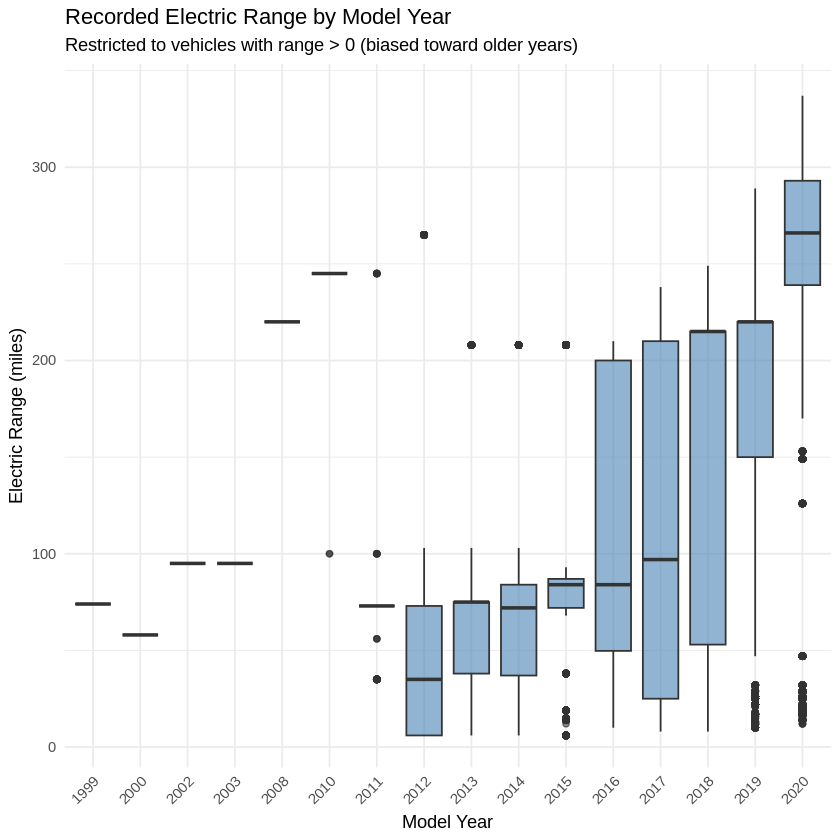

In [ ]:
ggplot(range_year, aes(x = factor(Model.Year), y = Electric.Range)) +
  geom_boxplot(fill = "steelblue", alpha = 0.6) +
  labs(
    title = "Recorded Electric Range by Model Year",
    subtitle = "Restricted to vehicles with range > 0 (biased toward older years)",
    x = "Model Year", y = "Electric Range (miles)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The Spearman test yielded a correlation coefficient of approximately 0.551. With a p-value less than 2.2e-16, which is much smaller than 0.05, we can conclude that there is a statistically significant positive monotonic relationship between the Model.Year and Electric.Range.

The Pearson test shows a correlation coefficient of approximately 0.505. The p-value indicates a statistically significant positive linear relationship between the Model.Year and Electric.Range.

Electric range does seem to have improved over time when excluding more recent data (after 2020). This exclusion is necessary because the electric ranges of new BEVs were no longer maintained in the dataset.

### Chi-Square Test of Independence (Facility Type vs. County Type):

This test is used to determine if there's a significant association between the distribution of Facility Type and whether a county is a High-EV or Low-EV county.

This would help us understand if different types of facilities are more prevalent in areas with high EV adoption compared to low EV adoption, which can inform targeted infrastructure development.


H0: Facility Type and County Type are independent. There is no association between facility type and whether a county is High-EV or Low-EV.

H1: Facility Type and County Type are not independent. There is an association between facility type and whether a county is High-EV or Low-EV.

In [ ]:
# combine High-EV and Low-EV station data
stations_high_ev$County.Type <- "High-EV"
stations_low_ev$County.Type <- "Low-EV"

stations_chi <- rbind(
  stations_high_ev[, c("Facility.Type", "County.Type")],
  stations_low_ev[, c("Facility.Type", "County.Type")]
)

# remove missing or blank Facility Types
stations_chi <- stations_chi[
  !is.na(stations_chi$Facility.Type) &
  trimws(stations_chi$Facility.Type) != "",
]

# create contingency table
facility_county_table <- table(
  stations_chi$Facility.Type,
  stations_chi$County.Type
)

print(facility_county_table)

                           
                            High-EV Low-EV
  AIRPORT                         3      0
  B_AND_B                         1      0
  BANK                            1      0
  BREWERY_DISTILLERY_WINERY       2      0
  CAR_DEALER                     12      0
  COLLEGE_CAMPUS                  8      0
  CONVENIENCE_STORE               1      0
  COOP                            1      0
  FED_GOV                         1      0
  FLEET_GARAGE                    2      0
  GAS_STATION                     4      2
  GROCERY                        12      1
  HOSPITAL                        3      0
  HOTEL                          63      5
  INN                             1      0
  LIBRARY                         3      0
  MULTI_UNIT_DWELLING             4      0
  MUNI_GOV                        2      0
  MUSEUM                          0      1
  OFFICE_BLDG                     4      0
  OTHER                          15      0
  OTHER_ENTERTAINMENT     

In [ ]:
# count observations for each facility type
facility_counts <- table(stations_chi$Facility.Type)

print(facility_counts)
# create grouped facility type
stations_chi$Facility.Group <- stations_chi$Facility.Type

stations_chi$Facility.Group[
  facility_counts[stations_chi$Facility.Type] < 10
] <- "OTHER"

# create contingency table
facility_group_table <- table(
  stations_chi$Facility.Group,
  stations_chi$County.Type
)

print(facility_group_table)

# chi-square test
chi_test <- chisq.test(facility_group_table)

print(chi_test)

# check assumptions
print(chi_test$expected)
mean(chi_test$expected < 5) * 100


                  AIRPORT                   B_AND_B                      BANK 
                        3                         1                         1 
BREWERY_DISTILLERY_WINERY                CAR_DEALER            COLLEGE_CAMPUS 
                        2                        12                         8 
        CONVENIENCE_STORE                      COOP                   FED_GOV 
                        1                         1                         1 
             FLEET_GARAGE               GAS_STATION                   GROCERY 
                        2                         6                        13 
                 HOSPITAL                     HOTEL                       INN 
                        3                        68                         1 
                  LIBRARY       MULTI_UNIT_DWELLING                  MUNI_GOV 
                        3                         4                         2 
                   MUSEUM               OFFICE_BLDG

Warning message in chisq.test(facility_group_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  facility_group_table
X-squared = 12.266, df = 7, p-value = 0.09214

                 
                   High-EV    Low-EV
  CAR_DEALER      11.31559 0.6844106
  GROCERY         12.25856 0.7414449
  HOTEL           64.12167 3.8783270
  OTHER           76.38023 4.6197719
  PARKING_GARAGE  10.37262 0.6273764
  PARKING_LOT     14.14449 0.8555133
  PUBLIC          26.40304 1.5969582
  SHOPPING_CENTER 33.00380 1.9961977


[1] 50

In [ ]:
# Chi-Square Test of Independence
chi_test <- chisq.test(facility_county_table)

print(chi_test)

Warning message in chisq.test(facility_county_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  facility_county_table
X-squared = 41.19, df = 33, p-value = 0.1549



In [ ]:
print(chi_test$expected)
mean(chi_test$expected < 5) * 100

                           
                               High-EV     Low-EV
  AIRPORT                    2.8288973 0.17110266
  B_AND_B                    0.9429658 0.05703422
  BANK                       0.9429658 0.05703422
  BREWERY_DISTILLERY_WINERY  1.8859316 0.11406844
  CAR_DEALER                11.3155894 0.68441065
  COLLEGE_CAMPUS             7.5437262 0.45627376
  CONVENIENCE_STORE          0.9429658 0.05703422
  COOP                       0.9429658 0.05703422
  FED_GOV                    0.9429658 0.05703422
  FLEET_GARAGE               1.8859316 0.11406844
  GAS_STATION                5.6577947 0.34220532
  GROCERY                   12.2585551 0.74144487
  HOSPITAL                   2.8288973 0.17110266
  HOTEL                     64.1216730 3.87832700
  INN                        0.9429658 0.05703422
  LIBRARY                    2.8288973 0.17110266
  MULTI_UNIT_DWELLING        3.7718631 0.22813688
  MUNI_GOV                   1.8859316 0.11406844
  MUSEUM              

[1] 83.82353

Fail to reject H0: There is no significant association between Facility Type and County Type.

# Conclusions

Overall, the analysis shows that EV ownership and public charging availability in Washington are strongly related, with counties that have more registered EVs generally having more charging stations. However, some counties, such as Snohomish County, appear to have fewer stations than expected based on their EV population, suggesting that infrastructure gaps still exist. The analysis also found a statistically significant relationship between model year and electric range, although the relationship was negative in this dataset, while facility type did not have a significant association with whether a county was classified as high-EV or low-EV. Based on these findings, stakeholders such as state agencies, local governments, and charging providers should focus future infrastructure investments on counties where charging availability is not keeping pace with EV ownership rather than relying only on overall EV counts. A limitation of this study is that the analysis was primarily conducted at the county level, which may hide differences within individual cities or ZIP codes, and the available variables do not fully capture factors such as charger capacity, usage, accessibility, or future demand. Future research could examine charging access at a more detailed geographic level, incorporate additional demographic and infrastructure variables, and track changes over time to identify where new charging stations would have the greatest impact.